# Module 11, Assignment 1: Large Language Models (Hands-On)

Welcome to **Module 8 Assignment: Large Language Models (Hands-On)**! This assignment contains five parts and five corresponding questions in MITLearn; throughout each of these five parts, we will apply what we learned in this module, including:

- **Part 1:** Implement **toy tokenization** and inspect token IDs/decoding
- **Part 2:** Train a tiny **autoregressive bigram language model** and try **greedy**, **top-k**, **top-p**, and **temperature** decoding
- **Part 3:** Build a minimal **scaled dot-product attention** demo and visualize attention weights
- **Part 4:** Practice **prompting strategies**: **zero-shot**, **few-shot**, and **chain-of-thought** using lightweight, local proxies (no external APIs)
- **Part 5:** Apply Parts 1-4 to a large language model, loaded locally from HuggingFace

All questions in this assignment should be answered in the MITLearn environment. For most of the questions, you should use the code and outputs in this notebook to answer these questions.


<a href="https://colab.research.google.com/github/yuri-spizhovyi-mit/ET6-ML/blob/main/module_11/mod11_assign1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>`


## Part 1 — Tokenization

The code blocks below build a tiny tokenizer with a mixed vocabulary, which means it includes some words and some subwords (part of a word). When a word is unknown, we fall back to subwords; if still unknown, we split to characters. A character is a basic unit of information that represents a letter, number, symbol, or control code.

First we import any necessary libraries.

In [ ]:
from typing import List

The code below defines the vocabulary for our tiny tokenizer. `VOCAB` is a dictionary mapping tokens → IDs and includes full words, subwords (## indicates continuation), and punctuation. `BASE_CHARS` builds fallback character vocab by assigning each letter to a unique ID starting at 3000. `UNK_ID` defines an ID for any unknown tokens. Together, these determine how the tokenizer breaks words into tokens.

In [ ]:
VOCAB = {
    # whole words
    "the": 1,
    "cat": 2,
    "sat": 3,
    "on": 4,
    "mat": 5,
    "elephant": 6,
    "greek": 7,
    "roman": 8,
    "is": 9,
    "are": 10,
    "in": 11,
    "a": 12,
    # subwords (prefix marked with "##")
    "un": 1001,
    "##break": 1002,
    "##able": 1003,
    "new": 1004,
    "##york": 1005,
    # punctuation/symbols
    ",": 2001,
    ".": 2002,
    ":": 2003,
    "?": 2004,
}

BASE_CHARS = {ch: 3000 + i for i, ch in enumerate(list("abcdefghijklmnopqrstuvwxyz"))}
UNK_ID = 0

The below code contains several functions that do the heavy-lifting and perform the tokenization.

`tokenize` lowercases text, then splits into alphabetic words and punctuation using the `regex` library. The result of this split are the tokens, e.g. `toks`.

The goal of `wordpiece_encode` is to encode each token by converting it to its corresponding ID. It iterates over the tokens. If the token is in the vocabulary, e.g. in VOCAB, then we just use the ID provided by the `VOCAB` vocabulary dictionary and skip any further checks. The middle lines manually define some rules to split special tokens into subwords. The last lines in the for-loop checks if these subwords are valid in the `VOCAB` dictionary. If they are, then we use the corresponding IDs from `VOCAB`. Otherwise, we use per-character IDs.

`decode` builds a reverse map, to go from the ID to a sentence. It does this by looping over the IDs. If the token ID is in `VOCAB`, then it handles the token's possible suffix, where the suffix is referred to by the variable `buffered_word`. If the suffix starts with `##`, then we combine the original word with the suffix, otherwise we simply discard the suffix. If the token ID is a per-character ID, then we use the character, and if the token ID is unknown, we use the placeholder `?`. Finally, the code joins all the words together by a space `" "` to produce the final sentence.

In [ ]:
def tokenize(text: str) -> list:
    import re

    toks = re.findall(r"[A-Za-z]+|[,:?.]", text.lower())
    return toks


def wordpiece_encode(tokens: list) -> list:
    ids = []
    for tok in tokens:
        # token exists in VOCAB
        if tok in VOCAB:
            ids.append(VOCAB[tok])
            continue

        # Manually define rules to split special tokens into subwords
        if tok.startswith("un") and tok.endswith("able"):
            parts = ["un", "##break", "##able"]
        elif tok == "newyork":
            parts = ["new", "##york"]
        else:
            parts = []

        # Map any resulting subwords to IDs if they exist in VOCAB, otherwise fall back to per-character IDs
        if parts and all(p in VOCAB for p in parts):
            ids.extend([VOCAB[p] for p in parts])
        else:
            ids.extend([BASE_CHARS.get(c, UNK_ID) for c in tok])
    return ids


def decode(ids: list) -> str:
    inv_vocab = {v: k for k, v in VOCAB.items()}
    inv_chars = {v: k for k, v in BASE_CHARS.items()}
    out, buffer_word = [], ""
    for i in ids:
        # Handle if token ID is in VOCAB
        if i in inv_vocab:
            piece = inv_vocab[i]
            if piece.startswith("##"):
                buffer_word += piece[2:]
            else:
                if buffer_word:
                    out.append(buffer_word)
                    buffer_word = ""
                out.append(piece)
        # If token ID is a per-character ID
        elif i in inv_chars:
            buffer_word += inv_chars[i]
        # If token ID is unknown
        else:
            buffer_word += "�"
    # Join words together
    if buffer_word:
        out.append(buffer_word)
    return " ".join(out)

The below code runs the above functions to tokenize, encode, and then decode the text `"The elephant sat on a newyork unbreakable mat"`.

In [ ]:
sample = "The elephant sat on a newyork unbreakable mat."
tokens = tokenize(sample)
ids = wordpiece_encode(tokens)
recon = decode(ids)
print("Text:", sample)
print("Tokens:", tokens)
print("IDs:", ids)
print("Decoded:", recon)

Text: The elephant sat on a newyork unbreakable mat.
Tokens: ['the', 'elephant', 'sat', 'on', 'a', 'newyork', 'unbreakable', 'mat', '.']
IDs: [1, 6, 3, 4, 12, 1004, 1005, 1001, 1002, 1003, 5, 2002]
Decoded: the elephant sat on a new york un breakable mat .


## Part 2 — Autoregressive text generation (small autoregressive language model)

We’ll train a bigram autoregressive language model (word-level) on a tiny corpus. Note that a bigram is a sequence of two adjacent tokens (like letters or words) from a string of text. You can think of this initial model as a much more simplified version of a large language model (LLM). We will use it as an example before we use a true LLM.

In this example, we will also experiment with different methods of decoding, including greedy, top-k, top-p (nucleus), and temperature.


First, we import any libraries we will need.

In [ ]:
import math, random, re
from collections import defaultdict, Counter

To train our toy autoregressive model, we first define a corpus, which is a structured collection of text or other data used to train and evaluate models. We use a small, multi-line training corpus consisting of two sentences, where the first sentence is repeated.

In [ ]:
corpus = """
To be or not to be that is the question .
Whether tis nobler in the mind to suffer .
To be or not to be that is the question .
"""

The below code first defines the function `simple_tokenize`, which is a simple tokenizer that lowercases text and returns a list of tokens consisting of the alphetic words or a period.

Then, the variable `tokens` are all tokens from the corpus. The variable `vocab` is the sorted unique tokens plus special `<BOS>` (begin) and `<EOS>` (end) tokens. The sorting makes it more stable for indexing purposes. The variables `stoi` and `itos` are string↔index maps, which are useful if you later need IDs.

In [ ]:
def simple_tokenize(text):
    return re.findall(r"[A-Za-z]+|[.]", text.lower())


tokens = simple_tokenize(corpus)
vocab = sorted(set(tokens + ["<BOS>", "<EOS>"]))
stoi = {s: i for i, s in enumerate(vocab)}
itos = {i: s for s, i in stoi.items()}

The below code trains our token autoregressive language model by first counting how often each token in the corpus is followed by the next token (e.g. "bigram frequencies") across the whole token stream in the corpus.


Then, we add "sentence-level transitions". In other words, we add `<BOS>` to the first word of each line and add last word to `<EOS>` to the last word. This lets the text generation start and stop sensibly, since autoregressive models generate text one-by-one.

In [ ]:
bigram_counts = defaultdict(Counter)
for i in range(len(tokens) - 1):
    bigram_counts[tokens[i]][tokens[i + 1]] += 1

for line in corpus.strip().splitlines():
    toks = simple_tokenize(line)
    if not toks:
        continue
    bigram_counts["<BOS>"][toks[0]] += 1
    bigram_counts[toks[-1]]["<EOS>"] += 1

The following code consists of many useful functions to perform the decoding part of the process.

The first five are helper functions for some of the decoding functions:

* `bigram_probs` converts bigram counts for a given context token into a probability distribution over next tokens. If the context was never seen, returns a uniform distribution over the vocab.

* `sample_from_dist` draws one token from a categorical distribution `dist` by a special kind of sampling called inverse cumulative distribution function sampling. See [here](https://blogs.sas.com/content/iml/2013/07/22/the-inverse-cdf-method.html) is you are more interested in learning more about this kind of sampling.

* `softmax_temp` applies temperature scaling to an existing distribution, where the input argument `T<1` sharpens (making the distribution more deterministic), `T>1` flattens (making the distribution more random). The function also uses `log/softmax` math for numerical stabilization purposes.

* `top_k` keeps only the k most probable tokens and renormalizes.

* `top_p` performs what is known as "nucleus (top-p) sampling", where the smallest set of tokens whose cumulative prob ≥ p is kept, then renormalized.

The last function `generate` actually performs the decoding, and does so differently depending on the type of decoding method. Starting from the `<BOS>` tag (signaling to start generating), each next generated token is picked repeatedly via either the greedy method (e.g. the token with highest probability), or from the `topk`, `topp`, or `temp` methods, which sample from a restricted/reshaped distribution according to the corresponding functions above. More specifically, `topk` samples using the `top_k` function, `topp` corresponds to the `top_p` function, and `temp` corresponds to the `softmax_temp` function. Next tokens are continuously generated until the `<EOS>` tag (signaling the end of generation) is reached, or when `max_len` is reached, which restricts the size of the generated sequence.



In [ ]:
def bigram_probs(context):
    counts = bigram_counts[context]
    total = sum(counts.values())
    if total == 0:
        return {w: 1 / len(vocab) for w in vocab}
    return {w: counts[w] / total for w in counts}


def sample_from_dist(dist):
    r, cum = random.random(), 0
    for w, p in dist.items():
        cum += p
        if r <= cum:
            return w
    return list(dist.keys())[-1]


def softmax_temp(dist, T=1.0):
    if T <= 0:
        T = 1e-6
    import numpy as np

    toks = list(dist.keys())
    probs = np.array([dist[t] for t in toks], float) + 1e-12
    logits = np.log(probs) / T
    exps = np.exp(logits - logits.max())
    new_probs = exps / exps.sum()
    return {t: float(p) for t, p in zip(toks, new_probs)}


def top_k(dist, k=3):
    items = sorted(dist.items(), key=lambda x: x[1], reverse=True)[:k]
    total = sum(p for _, p in items)
    return {w: p / total for w, p in items}


def top_p(dist, p=0.9):
    items = sorted(dist.items(), key=lambda x: x[1], reverse=True)
    cum, kept = 0.0, []
    for w, prob in items:
        kept.append((w, prob))
        cum += prob
        if cum >= p:
            break
    total = sum(prob for _, prob in kept)
    return {w: prob / total for w, prob in kept}


def generate(max_len=25, strategy="greedy", k=3, p=0.9, T=1.0):
    out, cur = [], "<BOS>"
    for _ in range(max_len):
        dist = bigram_probs(cur)
        if strategy == "greedy":
            nxt = max(dist, key=dist.get)
        elif strategy == "topk":
            nxt = sample_from_dist(top_k(dist, k=k))
        elif strategy == "topp":
            nxt = sample_from_dist(top_p(dist, p=p))
        elif strategy == "temp":
            nxt = sample_from_dist(softmax_temp(dist, T=T))
        else:
            nxt = sample_from_dist(dist)
        if nxt == "<EOS>":
            break
        out.append(nxt)
        cur = nxt
    return " ".join(out)

The below code calls the `generate` text with different decoding strategies, and we can see how the output differs by strategy.

In [ ]:
print("Greedy:", generate(strategy="greedy"))
print("Top-k:", generate(strategy="topk", k=2))
print("Top-p:", generate(strategy="topp", p=0.8))
print("Temp:", generate(strategy="temp", T=1.5))

Greedy: to be or not to be or not to be or not to be or not to be or not to be or not to
Top-k: whether tis nobler in the question .
Top-p: whether tis nobler in the question . whether tis nobler in the mind to be or not to be or not to be or not
Temp: to be that is the mind to be that is the question .


## Part 3 — Attention

Recall from lecture that in LLMs using the self-attention mechanism,the model computes for each token in the sequence:
* How much attention should be paid to other parts of the sequence (using Query and Key)
* What information should be gathered from those other parts (using Value).

$Q,K,V$ are three matrices representing the Query, Key, and Value respectively. Recall from lecture that Attention is a function of these matrices:
$$
\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$

In the code below, we will create random $Q,K,V$ matrices and compute attention:  


First we import

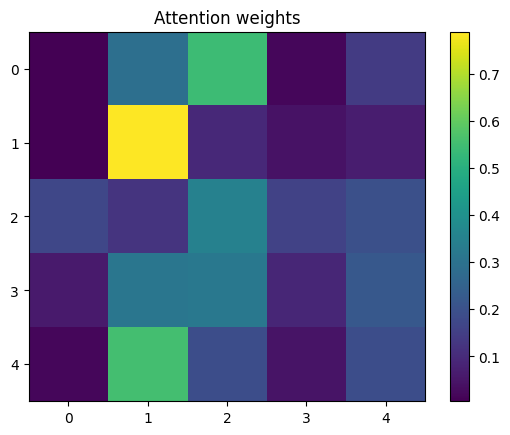

Row sums: [1. 1. 1. 1. 1.]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)


def attention(Q, K, V):
    dk = Q.shape[-1]
    scores = (Q @ K.T) / np.sqrt(dk)
    scores = scores - scores.max(axis=1, keepdims=True)
    attn = np.exp(scores)
    attn = attn / attn.sum(axis=1, keepdims=True)
    return attn, attn @ V


Q, K, V = np.random.randn(5, 4), np.random.randn(5, 4), np.random.randn(5, 4)
attn, out = attention(Q, K, V)

plt.imshow(attn, aspect="auto")
plt.colorbar()
plt.title("Attention weights")
plt.show()
print("Row sums:", attn.sum(axis=1))

## Part 4 — Prompting (Zero-shot, Few-shot, Chain-of-Thought)

The code below explores how different prompting strategies shape model behavior. Recall the various prompting strategies learned in lecture:

* **Zero-shot prompting** The model receives only natural-language instructions (no examples). It must infer the task directly from the phrasing.

* **Few-shot prompting** The model is guided by explicit demonstrations (examples of input–output pairs). This often improves accuracy by showing the expected pattern.

* **Chain-of-thought prompting** The model is encouraged to explain intermediate reasoning steps (“think step by step”), leading to more reliable answers on complex problems like arithmetic or logic.

Together, these strategies highlight that the quality of a model’s output depends heavily on the design of the prompt, not just the underlying model.

We first import any other libraries that we will need.

In [ ]:
import re
from collections import namedtuple

Below, we store demonstration examples with text (prompt) and label (task) in the variable `Example`.

For the few-shot learning strategy, we define `FEW_SHOT`, which is a small set of labeled examples representing different tasks.

In [ ]:
Example = namedtuple("Example", ["text", "label"])
FEW_SHOT = [
    Example("Translate this to Greek: Hello", "translate"),
    Example("Summarize this article", "summarize"),
    Example("Classify artifact as Greek or Roman", "classify"),
    Example("Write a poem about the sea", "creative"),
]

The below code includes functions for two strategies: zero-shot prompting and few-shot prompting.

The function `zero_shot` is a zero-shot classifier. More specifically, the function classifies the task purely based on keywords in the prompt. This mimics zero-shot prompting, where the model only gets instructions, no examples.

The function `few_shot` is a few-shot classifier. The function first tokenizes the prompt into words and compares the overlap with each token in the `FEW_SHOT` example. Then, it picks the label of the example with the highest word overlap. This mimics few-shot prompting, where the model sees input–output examples before classifying.

In [ ]:
def zero_shot(prompt: str) -> str:
    p = prompt.lower()
    if "translate" in p:
        return "translate"
    if "summarize" in p:
        return "summarize"
    if "classify" in p:
        return "classify"
    if "poem" in p or "story" in p:
        return "creative"
    return "unknown"


def few_shot(prompt: str, examples=FEW_SHOT) -> str:
    toks = set(re.findall(r"[a-z]+", prompt.lower()))
    best = ("unknown", 0)
    for ex in examples:
        ex_toks = set(re.findall(r"[a-z]+", ex.text.lower()))
        score = len(toks & ex_toks)
        if score > best[1]:
            best = (ex.label, score)
    return best[0]

The below code runs both strategies on the test prompts in `tests` and then prints how each approach classifies them.

In [ ]:
tests = [
    "Write a sonnet about black holes.",
    "Translate to Greek: Good morning",
    "Summarize this text.",
    "Classify a Roman vase.",
]
print("Zero-shot:")
[print(t, "->", zero_shot(t)) for t in tests]
print("\nFew-shot:")
[print(t, "->", few_shot(t)) for t in tests]

Zero-shot:
Write a sonnet about black holes. -> unknown
Translate to Greek: Good morning -> translate
Summarize this text. -> summarize
Classify a Roman vase. -> classify

Few-shot:
Write a sonnet about black holes. -> creative
Translate to Greek: Good morning -> translate
Summarize this text. -> summarize
Classify a Roman vase. -> classify


[None, None, None, None]

The below code defines a function to leverage chain-of-thought prompting to solve an arithmetic equation. In particular,this function extracts numbers and operations from the prompt using regex. It then builds the arithmetic expression sequentially. If the phrase “step by step” is included in the prompt, then the function outputs the intermediate reasoning steps (e.g., multiply first, then add). Otherwise, it just outputs the final result.

This example demonstrates how CoT prompting encourages the model to show its reasoning before the answer.

In [ ]:
def solve_arithmetic(prompt: str) -> str:
    numbers = list(map(int, re.findall(r"-?\d+", prompt)))
    ops = re.findall(r"[+\-*/]", prompt)
    if not numbers:
        return "No arithmetic"
    expr = str(numbers[0])
    steps = [f"Start {numbers[0]}"]
    for op, num in zip(ops, numbers[1:]):
        expr += f" {op} {num}"
        steps.append(f"Apply {op} {num} -> {eval(expr)}")
    result = eval(expr)
    if "step by step" in prompt.lower():
        return "Reasoning:\n- " + "\n- ".join(steps) + f"\nAnswer: {result}"
    else:
        return str(result)


print(solve_arithmetic("What is 3*5+2?"))
print(solve_arithmetic("Solve step by step: 3*5+2"))

17
Reasoning:
- Start 3
- Apply * 5 -> 15
- Apply + 2 -> 17
Answer: 17


---
## Part 5 — Using a Local Hugging Face Model (Tokenization, Prompting, and Attention)

This section shows how to interact with a local [Hugging Face](https://huggingface.co/) language model to perform the same tasks as in Parts 1-4. More specifically, we will:
<ol class="alpha-a" type="a">
  <li>Inspect tokenization</li>
  <li>Perform autoregressive generation under different decoding strategies</li>
  <li>Demonstrate prompting styles, including zero-shot (instructions only), few-shot (with examples), and chain-of-thought (ask for step-by-step reasoning)</li>
  <li>Expose attention weights for analysis/visualization</li>
</ol>

> Note: if you'd like to run this code yourself, make sure to switch your runtime to


Before we begin, ewe first need to import the appropriate libraries and load the local Huggingface model. This ensures a lightweight, reproducible local setup that works in CPU-only Colab sessions and allows quick experimentation.

In the code below, we try to import transformers/torch and if these are missing, then we install them. We set a fixed random seed for reproducibility. A seed is a nuber used to initialize a psuedorandom number generator so that, after setting the specific seed, any code using randomness will produce the same results. Note that setting another seed will change the results. For more information, see [here](https://en.wikipedia.org/wiki/Random_seed).

To load the model, we choose a tiny GPT-2-style model, `gpt2` for faster computation. Other options include `sshleifer/tiny-gpt2` (even smaller) and `gpt2/distilgpt2` (largest of the three). We also select the device, which means if we are using CPU or GPU (denoted by `cuda`). We then load the tokenizer and model, move the model to device, and set the model to `eval` mode, which means we will purely use it for inference/produce results rather than finetune or retrain the model. Finally, we print a summary of our model and device.

In [ ]:
# Install deps if needed (safe to re-run)
# In many Colab environments, transformers is preinstalled, but this ensures availability.
try:
    import transformers, torch
except ImportError:
    !pip -q install transformers accelerate torch --upgrade

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed

set_seed(42)

# Choose a small / tiny model for fast demos.
# Other options: "sshleifer/tiny-gpt2" (very small), "gpt2" (small), "distilgpt2"
MODEL_NAME = "gpt2"

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model.eval()

print(f"Loaded {MODEL_NAME} on device: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loaded gpt2 on device: cuda


### Section (a)

In this section, we will inspect the tokenization process of our small Huggingface language model.

The below code aims to encode a sample sentence (`sample_text`), collects their token IDs and their string tokens from our model's tokenizer, and decodes back to text. We also print out each of these steps (e.g. print text → tokens → IDs → decoded text). This is a nice way to visualize the subword/byte-level tokenization in order to see exactly what the model consumes.

In [ ]:
# Inspect tokenization: tokens, IDs, decode
sample_text = "Large language models are powerful."
enc = tokenizer(sample_text, return_tensors="pt")
input_ids = enc["input_ids"][0]
tokens = [tokenizer.convert_ids_to_tokens(i.item()) for i in input_ids]

print("Text:   ", sample_text)
print("Tokens: ", tokens)
print("IDs:    ", input_ids.tolist())
print("Decoded:", tokenizer.decode(input_ids))

Text:    Large language models are powerful.
Tokens:  ['Large', 'Ġlanguage', 'Ġmodels', 'Ġare', 'Ġpowerful', '.']
IDs:     [21968, 3303, 4981, 389, 3665, 13]
Decoded: Large language models are powerful.


### Section (b)

In this section, we will perform autoregressive generation under different decoding strategies including deterministic decoding via the greedy strategy and diverse decoding via the top-k and top-p strategies.

The following cell block aims to demonstrate the trade-off among decoding strategies without changing our core example model. We define the function `generate_text`, which wraps aorund the `model.enerate` function that our example model natively uses. Our function allows for us to control whether we are using a greedy (e.g. equivalent to temperature scaling strategy where T = 0), top-k, and top-p strategies.

We then run three the same prompt using these three strategies to contrast determinism (temp=0) vs. diversity (top-k/top-p).

In [ ]:
# Simple text generation helper with decoding strategy controls.
@torch.no_grad()
def generate_text(prompt, max_new_tokens=40, temperature=1.0, top_k=None, top_p=None):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    outputs = model.generate(
        **inputs,
        do_sample=(temperature is not None and temperature != 0),
        temperature=temperature if temperature else 1.0,
        top_k=top_k if top_k else 0,
        top_p=top_p if top_p else 1.0,
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


prompt = "In a distant future, scientists discovered"
print("Greedy-like (temp=0):")
print(generate_text(prompt, temperature=0.0, top_k=None, top_p=None))

print("\nSampling (temp=0.8, top_k=50):")
print(generate_text(prompt, temperature=0.8, top_k=50, top_p=None))

print("\nNucleus (temp=0.8, top_p=0.9):")
print(generate_text(prompt, temperature=0.8, top_k=None, top_p=0.9))

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Greedy-like (temp=0):
In a distant future, scientists discovered that the universe is expanding at a rate of about 1.5 billion times faster than the speed of light.

"We're not sure what the universe is doing at that speed," said lead

Sampling (temp=0.8, top_k=50):
In a distant future, scientists discovered that the universe is a multi-dimensional space.

The scientists, from the University of Texas at Austin, described the results of a series of experiments in which they used a telescope to see how

Nucleus (temp=0.8, top_p=0.9):
In a distant future, scientists discovered that even the smallest molecule of hydrogen can exist in an extremely strong form that can be stored in the DNA of bacteria. In a recent study, the scientists found a molecule that was different from the known


### Section (c)

In this section, we will perform demonstrate prompting styles, including zero-shot (instructions only), few-shot (with examples), and chain-of-thought (ask for step-by-step reasoning)

The below code performs zero-shot prompting to build a classification instruction with no examples. This zero-shot prompting is equivalent to calling `generate_text` with `temperature=0.0` to get a deterministic label without any inputs. This code illustrates how a model can follow plain instructions even without demonstration.

In [ ]:
# Zero-shot: ask for a task with instructions only (no examples).
zero_shot_prompt = (
    "Task: Classify the sentiment as Positive, Negative, or Neutral.\n"
    "Text: I loved the exhibit at the museum!\n"
    "Label:"
)
print("Zero-shot classification:")
print(generate_text(zero_shot_prompt, temperature=0.0))

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Zero-shot classification:
Task: Classify the sentiment as Positive, Negative, or Neutral.
Text: I loved the exhibit at the museum!
Label: "The Positive and Negative sentiment is a combination of positive and negative. The negative sentiment is a combination of positive and negative. The neutral sentiment is a combination of positive and negative. The positive sentiment is


Next, oru code performs few-shot prompting by calling `generate_text` with `temperature=0.0` and giving the model (input,output) pair examples before theq uery in order to elicit the most consistent label given the shown pattern.

> Note: You may notice that some outputs may not make sense. This is due to the size of the language model; since we are using smaller models, the risk of AI hallucination, which is a response generated by AI that contains false or misleading information, is higher. Read [here](https://en.wikipedia.org/wiki/Hallucination_(artificial_intelligence)) for more details on hallucination.

In [ ]:
# Few-shot: include demonstrations (input → output pairs) before the query.
few_shot_prompt = (
    "Task: Classify the sentiment as Positive, Negative, or Neutral.\n"
    "Text: The food was bland and the service was slow.\n"
    "Label: Negative\n\n"
    "Text: The day was fine, nothing special.\n"
    "Label: Neutral\n\n"
    "Text: What an absolutely fantastic performance!\n"
    "Label: Positive\n\n"
    "Text: I loved the exhibit at the museum!\n"
    "Label:"
)
print("Few-shot classification:")
print(generate_text(few_shot_prompt, temperature=0.0))

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Few-shot classification:
Task: Classify the sentiment as Positive, Negative, or Neutral.
Text: The food was bland and the service was slow.
Label: Negative

Text: The day was fine, nothing special.
Label: Neutral

Text: What an absolutely fantastic performance!
Label: Positive

Text: I loved the exhibit at the museum!
Label: Neutral

Text: I was so excited to see the exhibit!

Label: Neutral

Text: I was so excited to see the exhibit!

Label: Neutral

Text


In [ ]:
# CoT-style prompt: encourage intermediate reasoning in natural language.
# Note: Small models may not reliably follow CoT, but the pattern is correct for larger models.
cot_prompt = (
    "Solve the problem step by step and then give the final answer.\n"
    "Problem: If a train travels at 60 miles per hour for 1.5 hours, "
    "and then 40 miles per hour for 2 hours, what total distance did it cover?\n"
    "Reasoning:"
)
print("Chain-of-thought style prompt:")
print(generate_text(cot_prompt, temperature=0.7, top_p=0.9))

Chain-of-thought style prompt:
Solve the problem step by step and then give the final answer.
Problem: If a train travels at 60 miles per hour for 1.5 hours, and then 40 miles per hour for 2 hours, what total distance did it cover?
Reasoning: The answer is that it's a bit of a mystery.
Where did the train go?
When did it reach the point where it was supposed to go?
How did the train stop?


### Section (d)

In this section, we will expose the attention weights of our Hugging face language model for analysis/visualization. We will also

First we import our required libraries.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM

The code below does an initial exploration of the attention weights. We first reload our GPT model with the flag `output_attentions=True` so that we can request the attention weights from the model. The function `get_attentions` runs a forward pass of the model and returns the tuple of attention tensors (one per layer, with the shape shape `[batch, heads, seq, seq]`).

We then call `get_attentions` on an example text to obtain its attention weights. We print out the number of attention layers and the shape of the last layer of attention weights.

In [ ]:
# Note: Tiny GPT-2 variants generally support output_attentions=True.

# Reload with attentions enabled (same model object can also accept this flag per forward)
model_attn = (
    AutoModelForCausalLM.from_pretrained(MODEL_NAME, output_attentions=True)
    .to(device)
    .eval()
)


@torch.no_grad()
def run_with_attentions(prompt: str):
    enc = tokenizer(prompt, return_tensors="pt").to(device)
    out = model_attn(**enc, output_attentions=True)
    # attentions: tuple length = n_layers; each is [batch, n_heads, seq, seq]
    return enc, out.attentions


PROMPT = "Attention maps help us see which tokens focus on which."
enc, atts = run_with_attentions(PROMPT)
print(f"Layers: {len(atts)}, shape of last layer: {tuple(a.shape for a in atts[-1:])}")

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Layers: 12, shape of last layer: (torch.Size([1, 12, 12, 12]),)


The code below is quite complicated, so we will describe it in simpler terms. It is alright if you don't understand each step of the code. Please understand our explanation of the code here.

For ease of explanation, we have divided the code into several blocks and provide the corresponding explanation here:
1. We first use the output `enc, weights` from the previous code (which obtains the encoded text IDs and corresponding attention weight matrix) and obtain the corresponding tokens from these IDs. From this, we can determine how many attention layers we have, the size of each batch, the number of attention heads, and the sequence length, e.g. the number of tokens in the input after tokenization.
2. We choose to inspect the 0-th layer and 0-th attention head in that layer from the attention matrix. From this, we then extract the specific row `QUERY_POS` from the attention matrix; in our code below, we have set `QUERY_POS=5`, so we are interested in inspecting the 5th query token row (0-indexed).
3. From this, we obtain the top-attended tokens with weights by finding the $k$ tokens with the greatest attention weight.   
4. Finally, we produce shows a bar chart and heatmaps for quick visualization of the attention weights.


Prompt: Attention maps help us see which tokens focus on which.
Layer 0, Head 0, Query position 5 (token = 'Ġsee')
Sequence length = 12

Top attended tokens (index, token, weight):
    0           Att   0.3130
    2         Ġmaps   0.1924
    1        ention   0.1650
    3         Ġhelp   0.1455
    4           Ġus   0.1092
    5          Ġsee   0.0748
   10        Ġwhich   0.0000
   11             .   0.0000


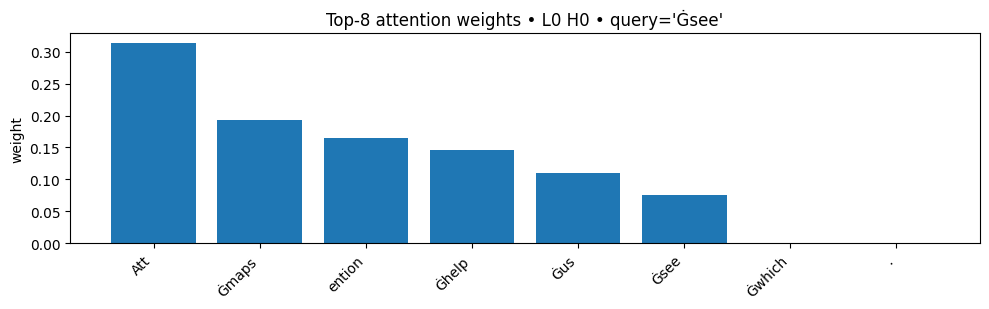

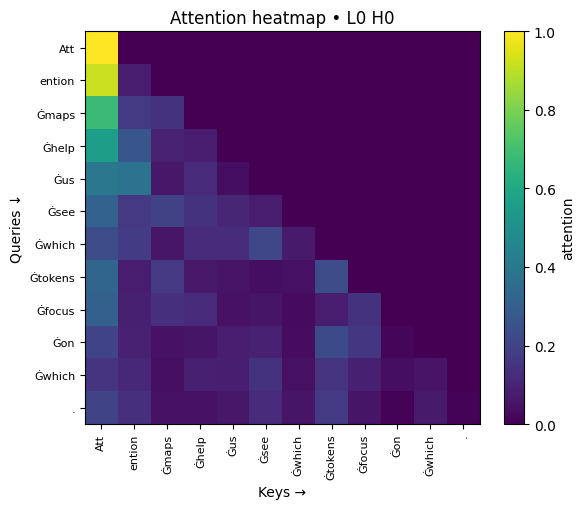

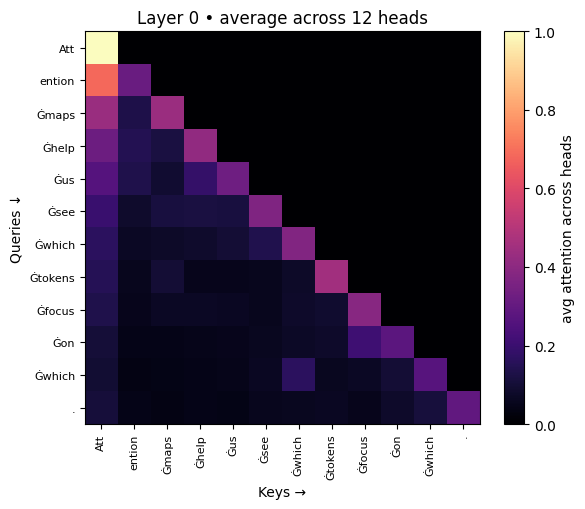

In [ ]:
# --- Attention row analysis + simple visualizations ---
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM

# ========= Config =========
PROMPT = "Attention maps help us see which tokens focus on which."
LAYER_IDX = 0  # which layer to inspect (0-based)
HEAD_IDX = 0  # which head in that layer (0-based)
QUERY_POS = 5  # which query token row to analyze (0-based)
TOPK = 8  # how many strongest keys to display
# =========================

# Ensure we have a model that returns attentions
try:
    model_attn
except NameError:
    model_attn = (
        AutoModelForCausalLM.from_pretrained(MODEL_NAME, output_attentions=True)
        .to(device)
        .eval()
    )


@torch.no_grad()
def run_with_attentions(prompt: str):
    enc = tokenizer(prompt, return_tensors="pt").to(device)
    out = model_attn(**enc, output_attentions=True)
    # attentions: tuple length = n_layers; each is [batch, n_heads, seq, seq]
    return enc, out.attentions


enc, atts = run_with_attentions(PROMPT)
input_ids = enc["input_ids"][0].tolist()
tokens = tokenizer.convert_ids_to_tokens(input_ids, skip_special_tokens=False)

n_layers = len(atts)
batch, n_heads, seq_len, _ = atts[LAYER_IDX].shape
assert QUERY_POS < seq_len, f"QUERY_POS {QUERY_POS} out of range (seq_len={seq_len})"

# Extract attention for selected layer/head
att_matrix = atts[LAYER_IDX][0, HEAD_IDX].detach().cpu().numpy()  # [seq, seq]
row = att_matrix[QUERY_POS]
row = row / (row.sum() + 1e-12)  # normalize

# Top-K tokens by attention weight
top_idx = np.argsort(row)[::-1][:TOPK]
top_pairs = [(idx, tokens[idx], float(row[idx])) for idx in top_idx]

print(f"\nPrompt: {PROMPT}")
print(
    f"Layer {LAYER_IDX}, Head {HEAD_IDX}, Query position {QUERY_POS} (token = {tokens[QUERY_POS]!r})"
)
print(f"Sequence length = {seq_len}\n")
print("Top attended tokens (index, token, weight):")
for idx, tok, w in top_pairs:
    print(f"  {idx:>3}  {tok:>12}   {w:.4f}")

# ---- Bar chart for the selected query row ----
plt.figure(figsize=(10, 3.2))
x = np.arange(len(top_idx))
labels = [tokens[i] for i in top_idx]
plt.bar(x, [row[i] for i in top_idx])
plt.xticks(x, labels, rotation=45, ha="right")
plt.title(
    f"Top-{TOPK} attention weights • L{LAYER_IDX} H{HEAD_IDX} • query='{tokens[QUERY_POS]}'"
)
plt.ylabel("weight")
plt.tight_layout()
plt.show()

# ---- Full heatmap for the selected head ----
plt.figure(figsize=(6, 5.2))
plt.imshow(att_matrix, cmap="viridis", aspect="auto")
plt.colorbar(label="attention")
plt.title(f"Attention heatmap • L{LAYER_IDX} H{HEAD_IDX}")
plt.xlabel("Keys →")
plt.ylabel("Queries ↓")
plt.xticks(range(seq_len), tokens, rotation=90, fontsize=8)
plt.yticks(range(seq_len), tokens, fontsize=8)
plt.tight_layout()
plt.show()

# ---- Average across heads at the layer ----
avg_head = atts[LAYER_IDX][0].detach().cpu().numpy().mean(axis=0)  # [seq, seq]
plt.figure(figsize=(6, 5.2))
plt.imshow(avg_head, cmap="magma", aspect="auto")
plt.colorbar(label="avg attention across heads")
plt.title(f"Layer {LAYER_IDX} • average across {n_heads} heads")
plt.xlabel("Keys →")
plt.ylabel("Queries ↓")
plt.xticks(range(seq_len), tokens, rotation=90, fontsize=8)
plt.yticks(range(seq_len), tokens, fontsize=8)
plt.tight_layout()
plt.show()

Let's take some time to analyze these visualizations.

#### Top-k attention row (printout and bar chart)
In the printout and the bar chart, we have inspected Layer 0, Head 0, Query position 5. The query token at that position was `'Ġsee'`. The printed output shows which tokens this query focused on most strongly:
*“Att” had the highest attention weight (0.31).
* “Ġmaps” (0.19), “ention” (0.16), “Ġhelp” (0.15), and “Ġus” (0.11) also received non-trivial attention.
* The query token itself (“Ġsee”) got some self-attention (0.07).
* Some tokens (like "Ġwhich" and ".") got essentially zero weight.

We can interpret these results as follows. When the model is processing the word “see,” it is attending most to the earlier word “Att” (from “Attention”), as well as parts of “maps” and “help.” In other words, it’s linking “see” to the context of “Attention maps help us…”, which is linguistically reasonable: the model is learning that “see” is semantically tied to “attention maps help.”

#### Attention heatmap (single head)
This heatmap shows the full query–key attention matrix for Layer 0, Head 0.Here, the rows are the query tokens, and the clumns are the key tokens. Note that brighter colors mean higher weights.

We can make several observations from this heatmap:
* Early tokens like “Att” get strong attention from many later tokens (the first column is bright across multiple rows).
* Attention is concentrated in the lower-left, which is typical for causal transformers: earlier tokens heavily influence later ones, but not the other way around (since it can’t attend to future positions).
* The distribution isn’t uniform: specific words (“Att,” “ention,” “maps”) act as “anchors” for many subsequent tokens.

#### Average attention across heads (layer 0)
This heatmap averages all 12 attention heads in layer 0. We can again make several observations from this heatmap:
* The heatmap is smoother than the single-head one.
* Still, we see strong average attention to the first token (“Att”) and parts of the phrase “Attention maps.”
* This shows redundancy: multiple heads converge on attending to the start of the sentence, which may serve as an anchor for encoding meaning.

#### Key Takeaways of attention

* **Query-specific focus** The token “see” doesn’t look everywhere equally — it attends to semantically relevant context (“Attention maps help…”).
* **Head specialization** The single-head view is sharp, while the averaged view is smoother. This suggests that individual heads specialize in specific roles, while the layer as a whole distributes attention more broadly.
* **Causal bias** Because this is GPT-like causal attention, tokens mostly attend backward in time (to earlier tokens), not forward. That’s why the bright regions hug the lower-left triangle.
* **Interpretability** Even tiny models show interpretable patterns — early words like “Attention” act as anchors that the rest of the sentence ties back to.

## Summary & Conclusion

In this notebook, we explored the **inner workings of large language models** through practical experiments. Starting with **model setup and tokenization**, we saw how text is transformed into token IDs that form the backbone of model inputs. We then compared **different text generation strategies**, learning how decoding parameters shape outputs from deterministic to creative.

We demonstrated how **prompt design** drives model behavior:

- Zero-shot prompts rely on instructions  
- Few-shot prompts add demonstrations  
- Chain-of-thought prompts encourage step-by-step reasoning  

Finally, we opened the “black box” with **attention analysis**, extracting and visualizing how tokens attend to each other. Heatmaps and row analyses showed how models link words together, often grounding later tokens in the context of earlier ones.


### Key Takeaways

- **Tokenization** is the bridge from human text to model-processable IDs.  
- **Decoding strategy** controls the balance between determinism and creativity.  
- **Prompting** is a powerful tool: the same model can behave differently with carefully crafted inputs.  
- **Attention maps** reveal that models don’t treat words equally — they focus selectively on context that matters for prediction.  

**Congratulations!** You’ve gained hands-on intuition for how LLMs read, generate, and reason, and you now have the tools to probe their behavior more deeply.